In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from utilities import impute_missing,replace_zeros_with_nan,create_features

ImportError: cannot import name 'impute_missing' from 'utilities' (c:\Users\Siddhant\diabetoes\diabetoes\utilities.py)

In [ ]:
df= pd.read_csv('diabetes.csv')


In [ ]:
col=[c for c in df.columns if c != df.columns[0]]
print(col)

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    count=(df[col]==0).sum()
    pct=count/len(df)*100
    print(f"{col} has {count} zero values which is {pct:.2f}% of the data")

Glucose has 5 zero values which is 0.65% of the data
BloodPressure has 35 zero values which is 4.56% of the data
SkinThickness has 227 zero values which is 29.56% of the data
Insulin has 374 zero values which is 48.70% of the data
BMI has 11 zero values which is 1.43% of the data


In [ ]:
df_clean = replace_zeros_with_nan(df, zero_cols)

print("\nMissing values AFTER replacement:")
print(df_clean.isnull().sum())
print(f"\nTotal missing: {df_clean.isnull().sum().sum()}")


Missing values AFTER replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing: 652



Glucose                  : 5

BloodPressure            : 35

SkinThickness            : 227

Insulin                  : 374

BMI                      : 11
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing: 652


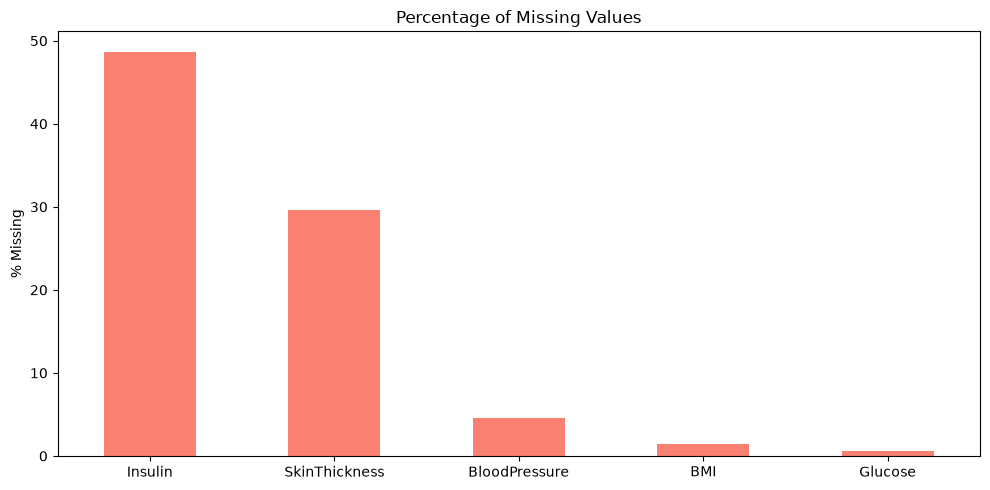

In [ ]:
df_missing = df.copy()


print(df_missing.isnull().sum())
print(f"\nTotal missing: {df_missing.isnull().sum().sum()}")
fig, ax = plt.subplots(figsize=(10, 5))
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot(kind="bar", color="salmon", ax=ax)
ax.set_title("Percentage of Missing Values")
ax.set_ylabel("% Missing")
plt.xticks(rotation=720)
plt.tight_layout()
plt.show()

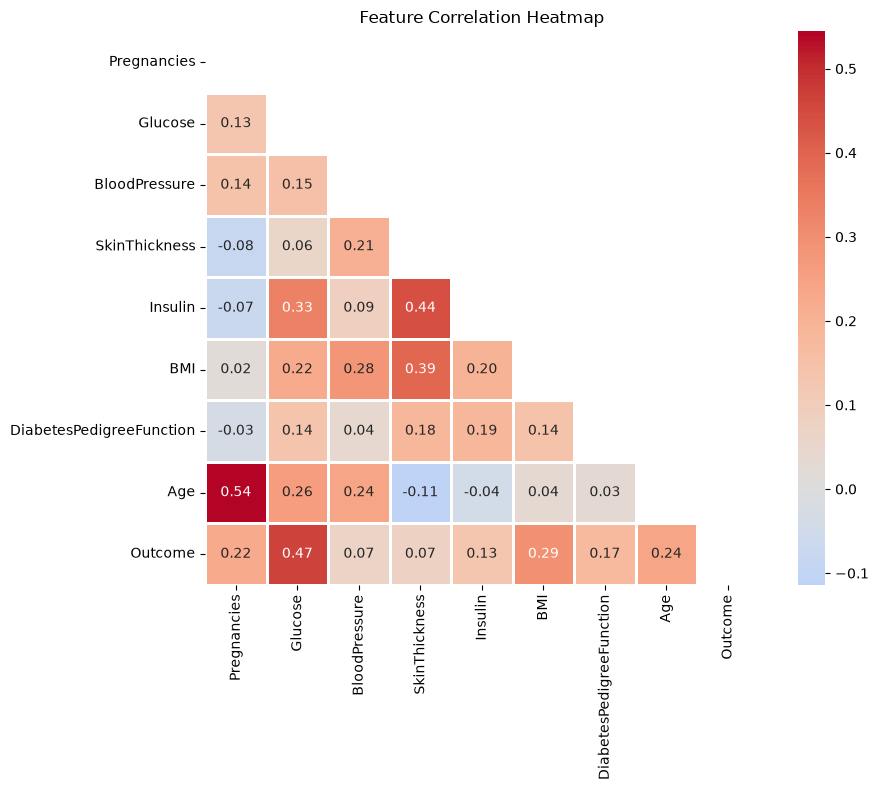

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:

df_feat = create_features(df_clean)
print(set(df_feat.columns) - set(df_clean.columns))
print(df_feat.head())

{'BMI_Category', 'BP_Category', 'Glucose_Category', 'Insulin_Category', 'AgeGroup'}
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome BMI_Category AgeGroup  \
0                     0.627   50        1        Obese      40s   
1                     0.351   31        0   Overweight      30s   
2                     0.672   32        1       Normal      30s   
3                     0.167   21        0   Overweight      20s   
4                     2.288   33        1        Obese      30s   

  Glucose_Category Insulin_Category BP_Category  
0         Diabetes            

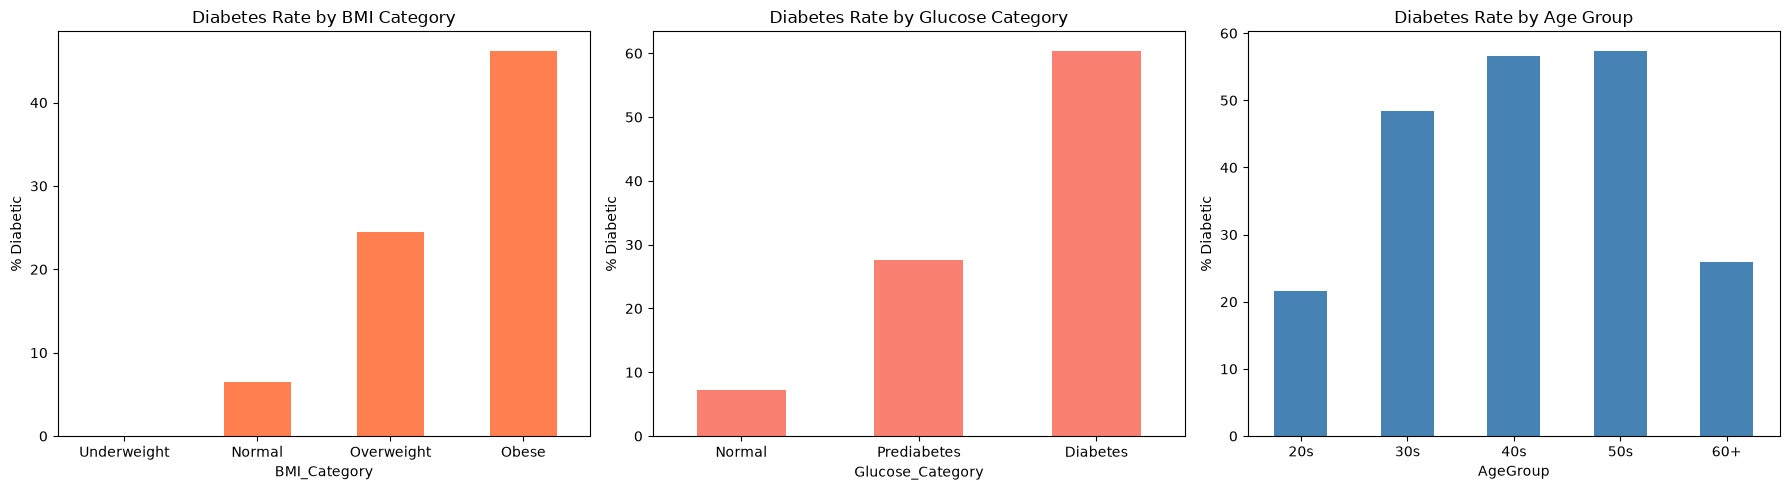

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#diabetes rate by bmi
bmi_rate = df_feat.groupby("BMI_Category")["Outcome"].mean() * 100
bmi_rate.plot(kind="bar", color="coral", ax=axes[0])
axes[0].set_title("Diabetes Rate by BMI Category")
axes[0].set_ylabel("% Diabetic")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
#diabetes rate by glucose
glucose_rate = df_feat.groupby("Glucose_Category")["Outcome"].mean() * 100
glucose_rate.plot(kind="bar", color="salmon", ax=axes[1])
axes[1].set_title("Diabetes Rate by Glucose Category")
axes[1].set_ylabel("% Diabetic")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
#diabetes rate by age group 
age_rate = df_feat.groupby("AgeGroup")["Outcome"].mean() * 100
age_rate.plot(kind="bar", color="steelblue", ax=axes[2])
axes[2].set_title("Diabetes Rate by Age Group")
axes[2].set_ylabel("% Diabetic")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [4]:
print("Diabetes rate by BMI Category:")
for cat in bmi_rate.index:
    n = (df_feat["BMI_Category"] == cat).sum()
    print(f"  {str(cat):15s}: {bmi_rate[cat]:.1f}% (n={n})")

print("\nDiabetes rate by Glucose Category:")
for cat in glucose_rate.index:
    n = (df_feat["Glucose_Category"] == cat).sum()
    print(f"  {str(cat):15s}: {glucose_rate[cat]:.1f}% (n={n})")



Diabetes rate by BMI Category:


NameError: name 'bmi_rate' is not defined

In [3]:
categorical_cols = ["BMI_Category", "AgeGroup", "Glucose_Category", "Insulin_Category", "BP_Category"]

df_encoded = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nColumns ({len(df_encoded.columns)}):")
for col in df_encoded.columns:
    print(f"  - {col} ({df_encoded[col].dtype})")

NameError: name 'df_feat' is not defined